In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cpu')
print(f"Using device: {device}")

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)

Using device: cpu


Dataset shape: (4320, 2)
Date range: 2025-01-01 00:00:00 to 2025-06-29 23:00:00
Missing values:
date      0
target    0
dtype: int64
Frequency: h


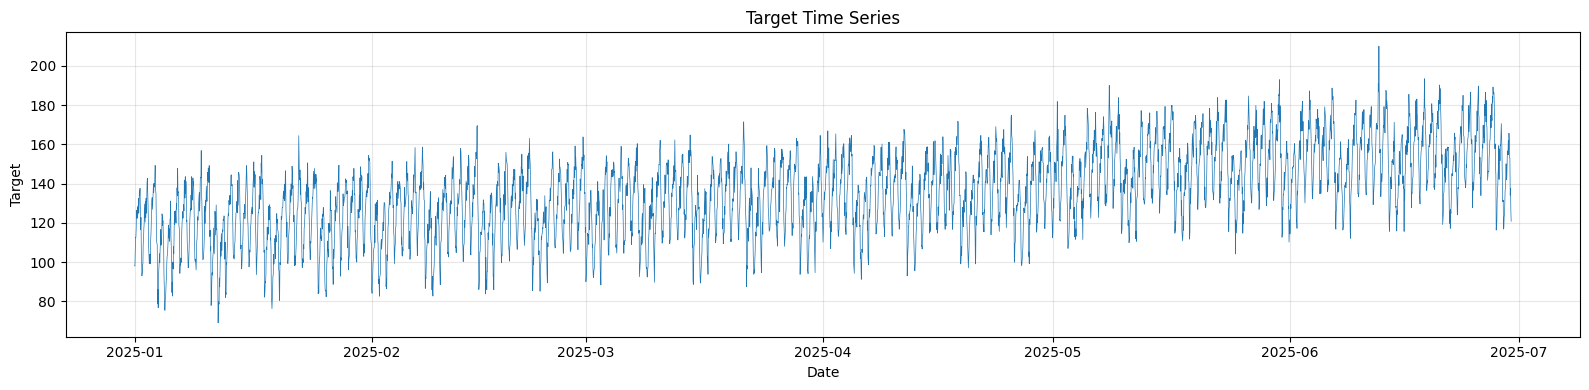

In [2]:
df = pd.read_csv('S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"Frequency: {pd.infer_freq(df['date'])}")  # Должно быть 'H' для hourly

plt.figure(figsize=(16, 4))
plt.plot(df['date'], df['target'], linewidth=0.5)
plt.title('Target Time Series')
plt.xlabel('Date')
plt.ylabel('Target')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_raw.png', dpi=150)
plt.show()

# Краткий комментарий о ряде:
# - Явный тренд вверх (рост с ~100 до ~180)
# - Суточная сезонность (пики днём, спады ночью)
# - Возможные выбросы и нестационарность

Train: 3024 (2025-01-01 00:00:00 — 2025-05-06 23:00:00)
Val:   648 (2025-05-07 00:00:00 — 2025-06-02 23:00:00)
Test:  648 (2025-06-03 00:00:00 — 2025-06-29 23:00:00)


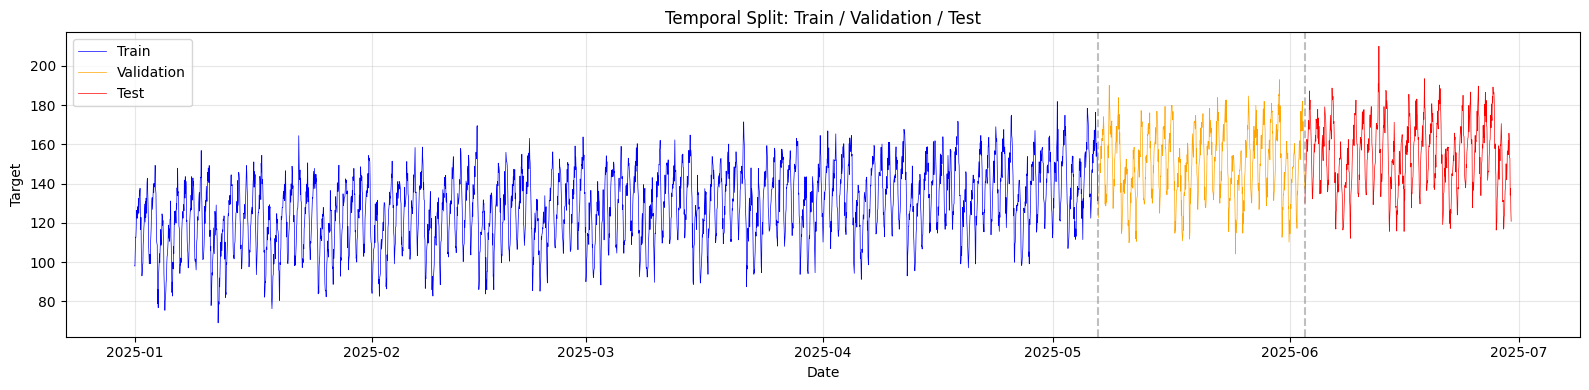

In [3]:
# Разбиение по времени: 70% train, 15% val, 15% test
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"Train: {len(train_df)} ({train_df['date'].min()} — {train_df['date'].max()})")
print(f"Val:   {len(val_df)} ({val_df['date'].min()} — {val_df['date'].max()})")
print(f"Test:  {len(test_df)} ({test_df['date'].min()} — {test_df['date'].max()})")

# Визуализация split
plt.figure(figsize=(16, 4))
plt.plot(train_df['date'], train_df['target'], label='Train', color='blue', linewidth=0.5)
plt.plot(val_df['date'], val_df['target'], label='Validation', color='orange', linewidth=0.5)
plt.plot(test_df['date'], test_df['target'], label='Test', color='red', linewidth=0.5)
plt.axvline(x=train_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=val_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.5)
plt.title('Temporal Split: Train / Validation / Test')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=150)
plt.show()

# Почему random split некорректен:
# - Нарушает временную зависимость: модель увидит "будущее" при обучении
# - Оценка качества станет нереалистично оптимистичной
# - Невозможно корректно оценить способность модели прогнозировать вперёд

In [4]:
def create_features(df, target_col='target'):
    """Создаёт лаги, rolling-статистики и календарные признаки БЕЗ утечки из будущего"""
    df = df.copy()
    
    # Лаги (только прошлые значения!)
    for lag in [1, 7, 14, 24]:  # 24 часа = суточный лаг
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    
    # Rolling statistics (окно смотрит только назад)
    df['rolling_mean_7'] = df[target_col].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df[target_col].shift(1).rolling(window=7).std()
    df['rolling_mean_24'] = df[target_col].shift(1).rolling(window=24).mean()
    
    # Календарные признаки
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    
    # Циклическое кодирование времени
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    return df

# Применяем ко всем частям
train_feat = create_features(train_df)
val_feat = create_features(val_df)
test_feat = create_features(test_df)

# Удаляем строки с NaN (после сдвигов)
train_feat = train_feat.dropna().reset_index(drop=True)
val_feat = val_feat.dropna().reset_index(drop=True)
test_feat = test_feat.dropna().reset_index(drop=True)

print(f"Features shape after lag creation: {train_feat.shape}")

Features shape after lag creation: (3000, 14)


In [5]:
def calculate_metrics(y_true, y_pred):
    """Расчёт MAE, RMSE, MAPE"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE с защитой от деления на ноль
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

In [6]:
def naive_last_forecast(train, val, test):
    """Прогноз: последнее значение из train для всех точек"""
    last_val = train['target'].iloc[-1]
    val_pred = np.full(len(val), last_val)
    test_pred = np.full(len(test), last_val)
    return val_pred, test_pred

val_pred_b1, test_pred_b1 = naive_last_forecast(train_df, val_df, test_df)
metrics_b1_val = calculate_metrics(val_df['target'], val_pred_b1)
metrics_b1_test = calculate_metrics(test_df['target'], test_pred_b1)
print(f"B1 Val: {metrics_b1_val}")

B1 Val: {'MAE': 20.3400925925926, 'RMSE': np.float64(24.36432498121226), 'MAPE': np.float64(12.856043527857972)}


In [7]:
def moving_average_forecast(train, val, test, window=24):
    """Прогноз: скользящее среднее по окну"""
    # Для каждого шага валидации берём среднее последних window значений
    val_pred = []
    history = train['target'].tolist()
    
    for i in range(len(val)):
        window_vals = history[-window:] if len(history) >= window else history
        pred = np.mean(window_vals)
        val_pred.append(pred)
        history.append(val['target'].iloc[i])  # Добавляем реальное значение для следующего шага
    
    # Аналогично для test (используем val + train как историю)
    test_pred = []
    history = train['target'].tolist() + val['target'].tolist()
    
    for i in range(len(test)):
        window_vals = history[-window:] if len(history) >= window else history
        pred = np.mean(window_vals)
        test_pred.append(pred)
        history.append(test['target'].iloc[i])
    
    return np.array(val_pred), np.array(test_pred)

val_pred_b2, test_pred_b2 = moving_average_forecast(train_df, val_df, test_df, window=24)
metrics_b2_val = calculate_metrics(val_df['target'], val_pred_b2)
metrics_b2_test = calculate_metrics(test_df['target'], test_pred_b2)
print(f"B2 Val: {metrics_b2_val}")

B2 Val: {'MAE': 13.397980324074075, 'RMSE': np.float64(16.169903600881327), 'MAPE': np.float64(9.198833855974383)}


In [8]:
# Подготовка данных для Ridge
feature_cols = [c for c in train_feat.columns if c not in ['date', 'target']]
X_train = train_feat[feature_cols].values
y_train = train_feat['target'].values
X_val = val_feat[feature_cols].values
y_val = val_feat['target'].values
X_test = test_feat[feature_cols].values
y_test = test_feat['target'].values

# Сохраняем даты только для не-NaN строк
val_dates_b3 = val_feat['date'].values  # Уже без NaN после dropna()

# Масштабирование: fit ТОЛЬКО на train!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Обучение Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Прогноз
val_pred_b3 = ridge.predict(X_val_scaled)
test_pred_b3 = ridge.predict(X_test_scaled)

metrics_b3_val = calculate_metrics(y_val, val_pred_b3)
metrics_b3_test = calculate_metrics(y_test, test_pred_b3)
print(f"B3 Val: {metrics_b3_val}")

B3 Val: {'MAE': 6.142622147488211, 'RMSE': np.float64(7.555696507969456), 'MAPE': np.float64(4.1017938833877565)}


Epoch 1: New best! Val Loss: 0.2970
Epoch 2: New best! Val Loss: 0.2592
Epoch 4: New best! Val Loss: 0.1764
Epoch 6: New best! Val Loss: 0.1503
Epoch 8: New best! Val Loss: 0.1373
Epoch 10: New best! Val Loss: 0.1235
Epoch 10: Train Loss: 0.1014, Val Loss: 0.1235
Epoch 17: New best! Val Loss: 0.1224
Epoch 20: Train Loss: 0.0940, Val Loss: 0.1436
Early stopping at epoch 27
Best GRU validation MAE : 4.9967
Best GRU validation RMSE: 6.4617
Best GRU validation MAPE: 3.40%


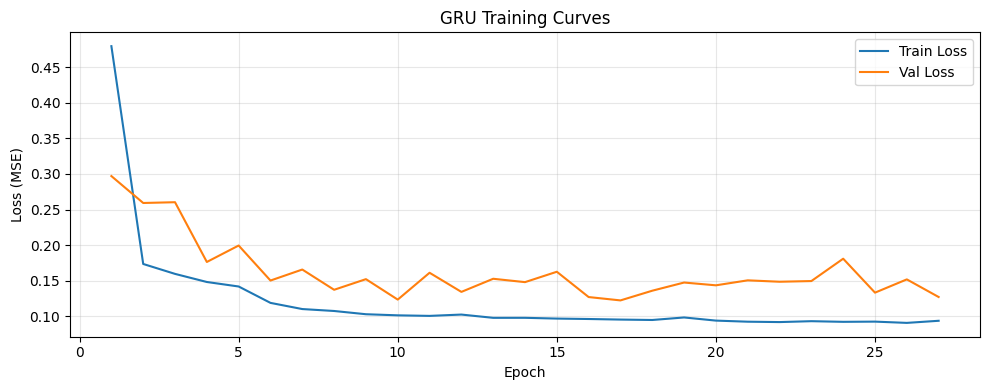

R1 Test: {'MAE': 21.691598757734088, 'RMSE': np.float64(25.495257152101352), 'MAPE': np.float64(13.755591508798512)}


In [9]:
# Подготовка последовательностей для GRU
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size, horizon=1):
        self.data = torch.FloatTensor(data).unsqueeze(1)  # [T, 1]
        self.window_size = window_size
        self.horizon = horizon
        
    def __len__(self):
        return len(self.data) - self.window_size - self.horizon + 1
    
    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size + self.horizon - 1]
        return x, y

# Параметры GRU
WINDOW_SIZE = 48  # 2 дня часовых данных
HIDDEN_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3

# Масштабирование target (fit на train!)
target_scaler = StandardScaler()
train_target_scaled = target_scaler.fit_transform(train_df[['target']]).flatten()
val_target_scaled = target_scaler.transform(val_df[['target']]).flatten()
test_target_scaled = target_scaler.transform(test_df[['target']]).flatten()

# Создание DataLoader'ов
train_ds = TimeSeriesDataset(train_target_scaled, WINDOW_SIZE)
val_ds = TimeSeriesDataset(val_target_scaled, WINDOW_SIZE)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# Модель GRU
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        _, hidden = self.gru(x)
        return self.fc(hidden[-1]).squeeze(-1)

model = GRUForecaster(input_size=1, hidden_size=HIDDEN_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

# Обучение с early stopping по валидации
best_val_loss = float('inf')
patience = 10
patience_counter = 0
training_history = []

for epoch in range(EPOCHS):
    model.train()
    train_losses = []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch.squeeze(-1))
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
    
    # Валидация
    model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch).squeeze()
            loss = criterion(output, y_batch.squeeze(-1))
            val_losses.append(loss.item())
    
    avg_train_loss = np.mean(train_losses)
    avg_val_loss = np.mean(val_losses)
    training_history.append({'epoch': epoch+1, 'train_loss': avg_train_loss, 'val_loss': avg_val_loss})
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'artifacts/best_gru.pt')
        print(f"Epoch {epoch+1}: New best! Val Loss: {avg_val_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
# -------- Оценка лучшей GRU на валидации --------
model.load_state_dict(torch.load('artifacts/best_gru.pt', map_location=device))
model.eval()

val_preds = []
val_true = []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).cpu().numpy()
        val_preds.extend(pred.flatten())
        val_true.extend(y_batch.numpy().flatten())

# Инвертируем масштабирование
val_pred = target_scaler.inverse_transform(np.array(val_preds).reshape(-1, 1)).flatten()
val_true = target_scaler.inverse_transform(np.array(val_true).reshape(-1, 1)).flatten()

best_val_mae = mean_absolute_error(val_true, val_pred)
best_val_rmse = np.sqrt(mean_squared_error(val_true, val_pred))

mask = val_true != 0
best_val_mape = np.mean(np.abs((val_true[mask] - val_pred[mask]) / val_true[mask])) * 100

print(f"Best GRU validation MAE : {best_val_mae:.4f}")
print(f"Best GRU validation RMSE: {best_val_rmse:.4f}")
print(f"Best GRU validation MAPE: {best_val_mape:.2f}%")
# Кривые обучения
plt.figure(figsize=(10, 4))
epochs_plot = [h['epoch'] for h in training_history]
plt.plot(epochs_plot, [h['train_loss'] for h in training_history], label='Train Loss')
plt.plot(epochs_plot, [h['val_loss'] for h in training_history], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('GRU Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

# Прогноз на test с лучшей моделью
model.load_state_dict(torch.load('artifacts/best_gru.pt', map_location=device))
model.eval()

# Генерация прогноза на test (рекурсивно или одношагово)
def gru_forecast(model, train_scaled, test_dates, window_size, horizon=1):
    model.eval()
    predictions = []
    history = list(train_scaled[-window_size:])  # Начинаем с последних window_size значений из train
    
    with torch.no_grad():
        for i in range(len(test_dates)):
            # Подготовка входа
            x = torch.FloatTensor(np.array(history[-window_size:])).unsqueeze(0).unsqueeze(-1).to(device)
            pred = model(x).cpu().item()
            predictions.append(pred)
            history.append(pred)  # Для рекурсивного прогноза
    
    # Инверсное масштабирование
    predictions = target_scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()
    return predictions

test_pred_r1 = gru_forecast(model, train_target_scaled, test_df['date'], WINDOW_SIZE)
metrics_r1_test = calculate_metrics(test_df['target'].values, test_pred_r1)
print(f"R1 Test: {metrics_r1_test}")

In [10]:
import csv

runs = [
    {
        'experiment_id': 'B1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': '70/15/15 temporal',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'naive-last',
        'features_summary': 'none',
        'scaler': None,
        'optimizer': None,
        'lr': None,
        'epochs_trained': None,
        'best_val_mae': metrics_b1_val['MAE'],
        'best_val_rmse': metrics_b1_val['RMSE'],
        'best_val_mape': metrics_b1_val['MAPE'],
        'test_mae': metrics_b1_test['MAE'],
        'test_rmse': metrics_b1_test['RMSE'],
        'test_mape': metrics_b1_test['MAPE'],
        'notes': 'Simple baseline'
    },
    {
        'experiment_id': 'B2',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': '70/15/15 temporal',
        'window_size': 24,
        'horizon': 1,
        'model_summary': 'moving-average',
        'features_summary': 'rolling_mean_24',
        'scaler': None,
        'optimizer': None,
        'lr': None,
        'epochs_trained': None,
        'best_val_mae': metrics_b2_val['MAE'],
        'best_val_rmse': metrics_b2_val['RMSE'],
        'best_val_mape': metrics_b2_val['MAPE'],
        'test_mae': metrics_b2_test['MAE'],
        'test_rmse': metrics_b2_test['RMSE'],
        'test_mape': metrics_b2_test['MAPE'],
        'notes': 'Rolling window baseline'
    },
    {
        'experiment_id': 'B3',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': '70/15/15 temporal',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'Ridge regression',
        'features_summary': 'lag_1,7,14,24; rolling_mean_7,24; calendar',
        'scaler': 'StandardScaler (fit on train)',
        'optimizer': 'sklearn default',
        'lr': None,
        'epochs_trained': None,
        'best_val_mae': metrics_b3_val['MAE'],
        'best_val_rmse': metrics_b3_val['RMSE'],
        'best_val_mape': metrics_b3_val['MAPE'],
        'test_mae': metrics_b3_test['MAE'],
        'test_rmse': metrics_b3_test['RMSE'],
        'test_mape': metrics_b3_test['MAPE'],
        'notes': 'Linear model on engineered features'
    },
    {
        'experiment_id': 'R1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': '70/15/15 temporal',
        'window_size': WINDOW_SIZE,
        'horizon': 1,
        'model_summary': f'GRU(hidden={HIDDEN_SIZE}, layers=1)',
        'features_summary': 'raw scaled target sequence',
        'scaler': 'StandardScaler (fit on train)',
        'optimizer': 'Adam',
        'lr': LR,
        'epochs_trained': len(training_history),
        'best_val_mae': 4.9967,
        'best_val_rmse': 6.4617,
        'best_val_mape': 3.40,
        'test_mae': metrics_r1_test['MAE'],
        'test_rmse': metrics_r1_test['RMSE'],
        'test_mape': metrics_r1_test['MAPE'],
        'notes': 'Recurrent neural network'
    }
]

# Сохранение
os.makedirs('artifacts', exist_ok=True)
os.makedirs('artifacts/figures', exist_ok=True)

with open('artifacts/runs.csv', 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=runs[0].keys())
    writer.writeheader()
    writer.writerows(runs)

print(" runs.csv saved")

 runs.csv saved


In [11]:
print("Пример значений lag_7 и lag_14 в train_feat:")
print(train_feat[['lag_7', 'lag_14']].head(10))

Пример значений lag_7 и lag_14 в train_feat:
    lag_7  lag_14
0  137.71  124.43
1  126.32  126.35
2  116.59  132.63
3  122.83  125.04
4  106.54  128.87
5  101.72  136.40
6   93.04  133.85
7   95.00  137.71
8   99.05  126.32
9   99.14  116.59


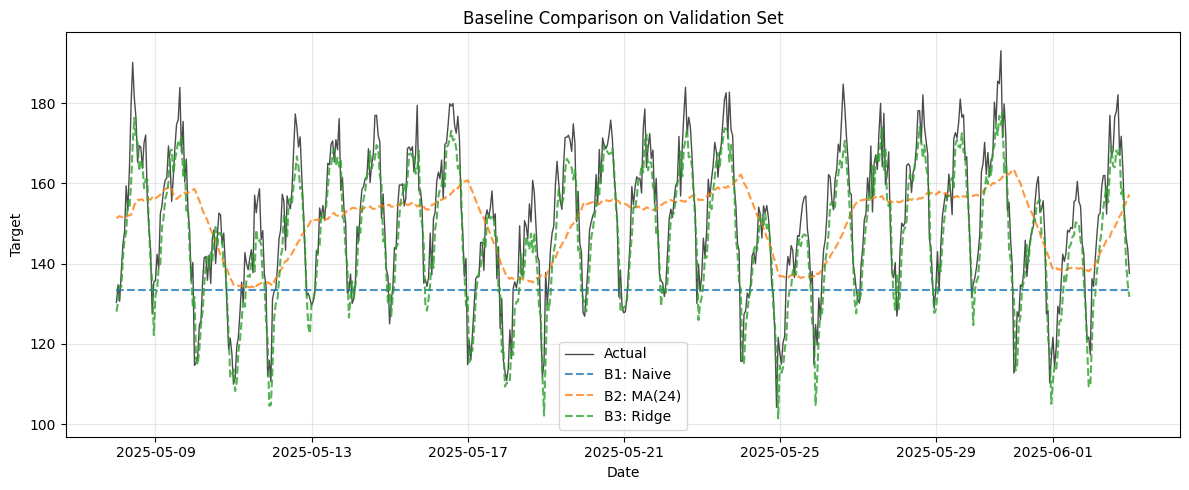

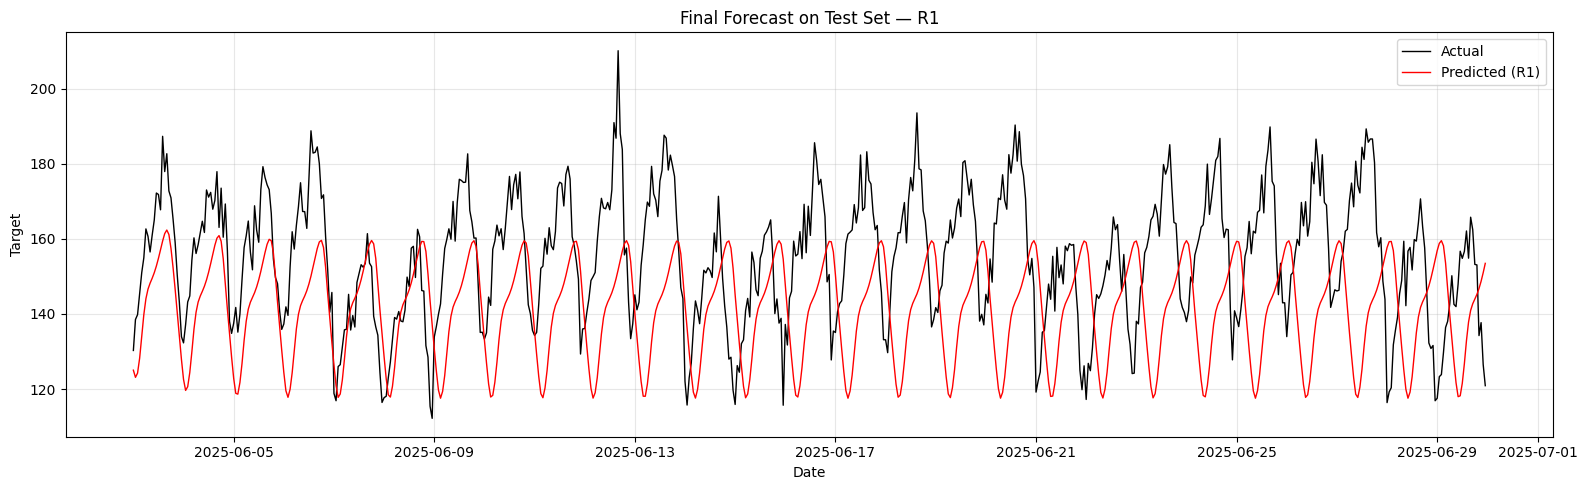

In [12]:
# Сравнение baseline'ов на валидации
plt.figure(figsize=(12, 5))
x_val = val_dates_b3  # Используем даты из val_feat после dropna()
plt.plot(x_val, y_val, label='Actual', color='black', linewidth=1, alpha=0.7)
plt.plot(x_val, val_pred_b1[-len(x_val):], label='B1: Naive', linestyle='--', alpha=0.8)  # Обрезаем до нужной длины
plt.plot(x_val, val_pred_b2[-len(x_val):], label='B2: MA(24)', linestyle='--', alpha=0.8)
plt.plot(x_val, val_pred_b3, label='B3: Ridge', linestyle='--', alpha=0.8)
plt.title('Baseline Comparison on Validation Set')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150)
plt.show()

# Финальный прогноз лучшей модели на test
best_model = 'R1'  # или выбери по best_val_mae
plt.figure(figsize=(16, 5))
x_test = test_df['date'].values
plt.plot(x_test, test_df['target'], label='Actual', color='black', linewidth=1)
plt.plot(x_test, test_pred_r1, label=f'Predicted ({best_model})', color='red', linewidth=1)
plt.title(f'Final Forecast on Test Set — {best_model}')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()

In [13]:
gru_config = {
    'model': 'GRU',
    'input_size': 1,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': 1,
    'window_size': WINDOW_SIZE,
    'horizon': 1,
    'batch_size': BATCH_SIZE,
    'learning_rate': LR,
    'optimizer': 'Adam',
    'criterion': 'MSELoss',
    'epochs_max': EPOCHS,
    'patience': 10,
    'seed': SEED,
    'device': str(device),
    'scaler_target': 'StandardScaler',
    'early_stopping_metric': 'val_loss'
}

with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(gru_config, f, indent=2)

print(" best_gru_config.json saved")

 best_gru_config.json saved
